In [1]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Step 2: Load the dataset
df = pd.read_excel(r"G:\My Drive\3. Carino\MSC\Dissertation\ML\Gender Prediction using FootPrints\dataset\dataset_150.xlsx")


#### EDA on Full DF

In [3]:
# Step 3: Basic Dataset info
print("Dataset Shape:", df.shape)
print("-"*30)

print("\nColumn Names:\n", df.columns)
print("-"*30)

print("\nData Types:\n")
print("-"*30)

print(df.dtypes)


Dataset Shape: (150, 18)
------------------------------

Column Names:
 Index(['S_No', 'FootSide', 'Foot_Length_cm', 'Foot_Breadth_cm', 'Foot_Index',
       'Midfoot_Width_cm', 'Toe1_Length_cm', 'Toe2_Length_cm',
       'Toe3_Length_cm', 'Toe4_Length_cm', 'Toe5_Length_cm', 'Ball_Breadth_cm',
       'Breadth_Ball_index', 'Heel_Breadth_cm', 'Heel_Breadth_Index',
       'Arch_Length_cm', 'Arch_Index', 'Sex'],
      dtype='object')
------------------------------

Data Types:

------------------------------
S_No                    int64
FootSide               object
Foot_Length_cm        float64
Foot_Breadth_cm       float64
Foot_Index            float64
Midfoot_Width_cm      float64
Toe1_Length_cm        float64
Toe2_Length_cm        float64
Toe3_Length_cm        float64
Toe4_Length_cm        float64
Toe5_Length_cm        float64
Ball_Breadth_cm       float64
Breadth_Ball_index    float64
Heel_Breadth_cm       float64
Heel_Breadth_Index    float64
Arch_Length_cm        float64
Arch_Index  

In [4]:
# remove unused columns like S_No
df.drop(columns=['S_No'], inplace=True)


In [5]:
# Step 5: Check for missing values
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

FootSide              0
Foot_Length_cm        0
Foot_Breadth_cm       0
Foot_Index            0
Midfoot_Width_cm      0
Toe1_Length_cm        0
Toe2_Length_cm        0
Toe3_Length_cm        0
Toe4_Length_cm        0
Toe5_Length_cm        0
Ball_Breadth_cm       0
Breadth_Ball_index    0
Heel_Breadth_cm       0
Heel_Breadth_Index    0
Arch_Length_cm        0
Arch_Index            0
Sex                   0
dtype: int64


In [6]:
# Step 6: Describe numeric columns
display(df.describe())


,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,23.215333,8.374667,36.340000,2.460667,23.088667,22.788000,21.970667,20.802667,19.324000,8.861333,38.334667,4.756667,20.609333,7.053333,0.148600
std,2.025036,0.885315,5.931748,1.229552,1.394839,1.352101,1.345564,1.320461,1.224892,1.058033,3.801359,0.529076,2.029658,2.021982,0.068434
min,8.000000,3.400000,15.600000,0.000000,19.300000,19.200000,18.400000,17.500000,16.500000,0.000000,0.000000,3.000000,14.500000,0.000000,0.000000
25%,22.300000,7.825000,34.500000,1.600000,22.400000,21.800000,21.000000,19.825000,18.500000,8.300000,37.025000,4.400000,19.100000,6.250000,0.110000
50%,23.250000,8.500000,36.000000,2.500000,23.000000,22.750000,22.000000,20.900000,19.400000,9.000000,38.600000,4.800000,20.600000,7.500000,0.150000
75%,24.400000,9.000000,37.700000,3.000000,24.075000,23.800000,23.000000,21.775000,20.375000,9.500000,39.975000,5.175000,22.175000,8.475000,0.180000
max,27.100000,10.400000,100.000000,6.300000,26.000000,25.500000,24.600000,23.400000,21.500000,10.600000,44.400000,5.900000,25.600000,10.600000,0.570000


FootSide
Left     100
Right     50
Name: count, dtype: int64


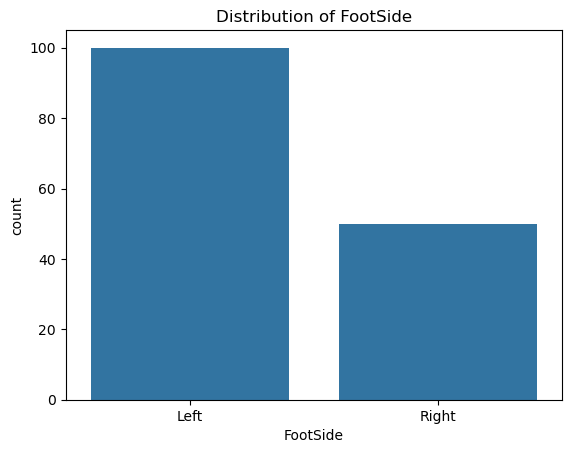

In [11]:
# Step 7: Check Footside Counts
print(df['FootSide'].value_counts())

sns.countplot(x='FootSide', data=df)
plt.title("Distribution of FootSide")
plt.show()


Sex
Male      100
Female     50
Name: count, dtype: int64


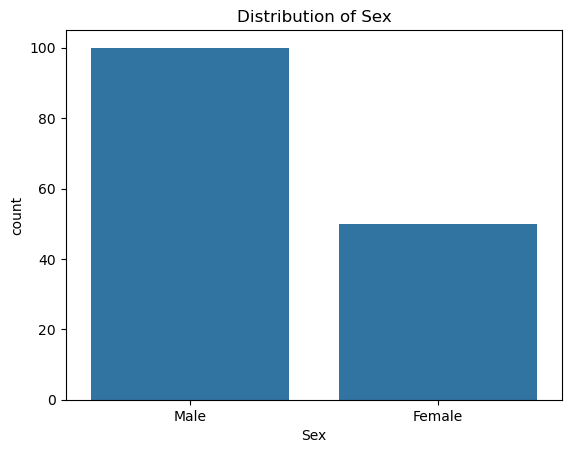

In [12]:
# Step 7: Check Footside Counts
print(df['Sex'].value_counts())

sns.countplot(x='Sex', data=df)
plt.title("Distribution of Sex")
plt.show()


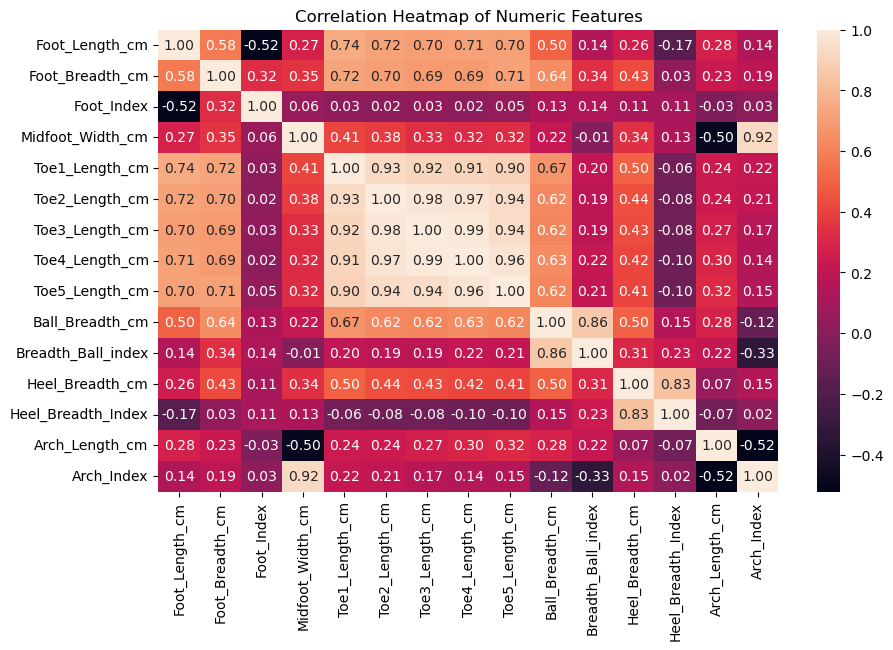

In [13]:
# --- Correlation Heatmap to check col to col relationship ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


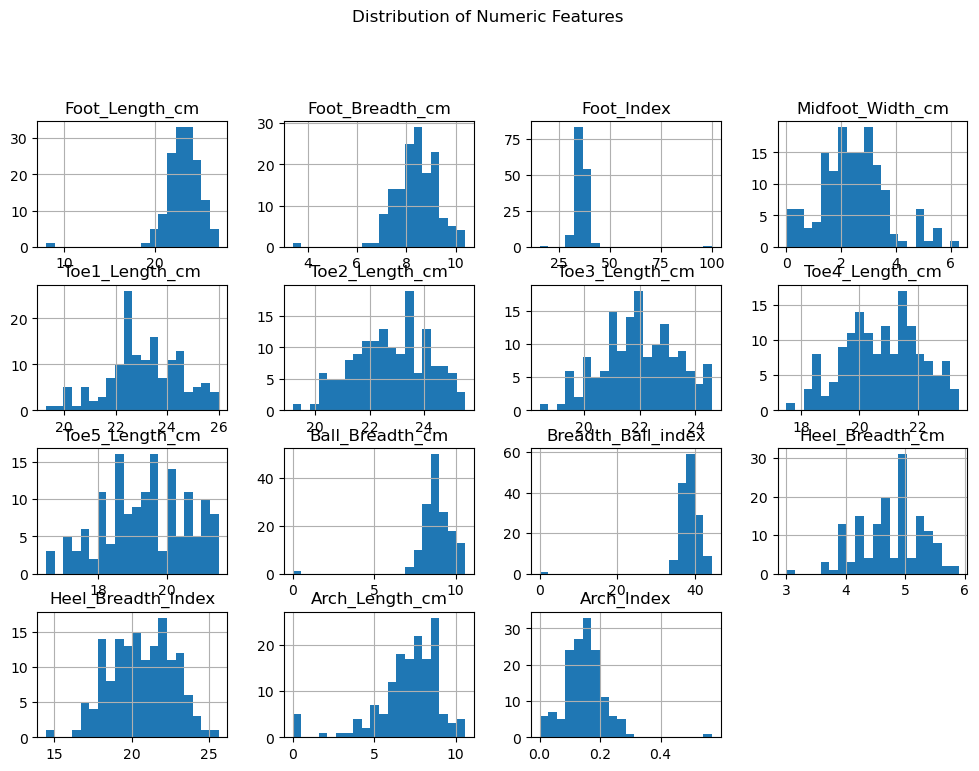

In [14]:
# --- Histograms for numeric features distribution ---
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.show()


C:\Users\jaina\AppData\Local\Temp\ipykernel_14744\838531861.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette='viridis')


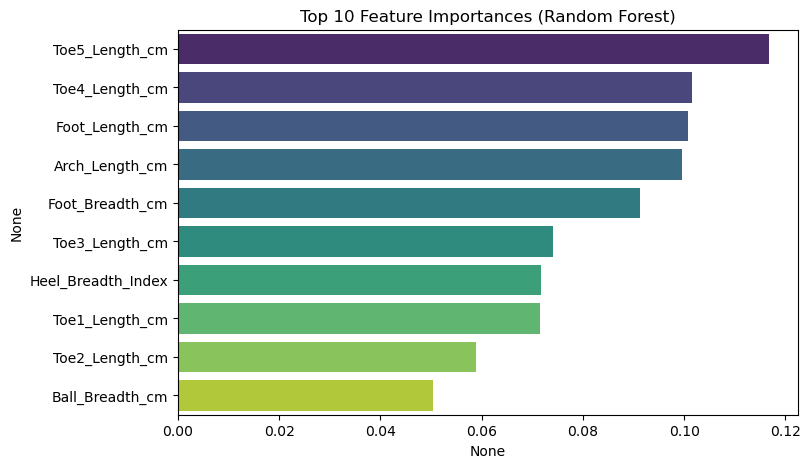

In [15]:
# Top 10 Important Features for whole dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Sex'])
# Exclude 'Sex' from features
X = df.drop('Sex', axis=1).select_dtypes(include=np.number)

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette='viridis')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()
